# Crossover Type Experiment

This notebook investigates how the choice of crossover operator affects the convergence of a Genetic Algorithm applied to image approximation using 100 semi-transparent triangles.

Three crossover strategies (one_point, uniform and none) are compared under identical conditions to measure their individual contribution to the optimization process.

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
from ga_core import *

# Reproducibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Configuration

All parameters below are fixed across the three experiments. Only the crossover type varies, ensuring a fair and isolated comparison.



In [3]:
POP_SIZE = 30
GENERATIONS = 1000

ELITE_SIZE = 3
TOURNAMENT_SIZE = 5

CROSSOVER_TYPES = [
    "one_point",
    "uniform",
    "none"
]

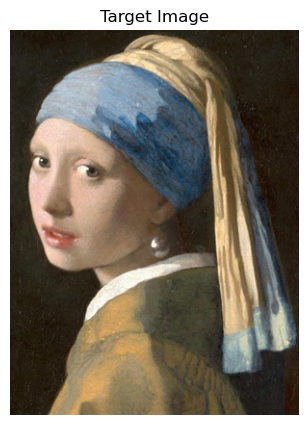

In [4]:
target = load_target_image("girl_pearl_earing.png")

plt.figure(figsize=(4, 5))
plt.imshow(target)
plt.title("Target Image")
plt.axis("off")
plt.show()

## Experiment Function

The function below runs the GA for each crossover type. The three strategies tested are:

- `one_point` — splits the triangle list at a random position and combines both halves from different parents;
- `uniform` — selects each triangle independently from either parent with 50% probability;
- `none` — no recombination occurs, serving as a baseline to measure the isolated effect of mutation.

In [5]:
def run_crossover_experiment(
    target_img,
    crossover_types,
    pop_size=POP_SIZE,
    generations=GENERATIONS,
    elite_size=ELITE_SIZE,
    tournament_size=TOURNAMENT_SIZE
):
    """
    Runs the GA with different crossover types.
    All other GA parameters remain constant.
    """
    results = {}

    for crossover_type in crossover_types:
        print("=" * 60)
        print(f"Testing crossover type: {crossover_type}")

        result = evolve_configurable(
            target_img=target_img,
            pop_size=pop_size,
            generations=generations,
            mutation_rate=0.05,
            elite_size=elite_size,
            selection_type="tournament",
            tournament_size=tournament_size,
            crossover_type=crossover_type,
            crossover_rate=0.9,
            use_mutation_decay=False,
            snapshot_generations=[0, generations - 1],
            print_every=100
        )

        best_rend = render_individual(
            result["best_individual"],
            result["background_color"]
        )

        final_rmse = calculate_fitness(best_rend, target_img)

        results[crossover_type] = {
            "best_individual": result["best_individual"],
            "history": result["history"],
            "background_color": result["background_color"],
            "snapshots": result["snapshots"],
            "final_image": best_rend,
            "final_rmse": final_rmse
        }

        print(f"Final RMSE for {crossover_type}: {final_rmse:.4f}")

    return results

## Running the Experiments

Each crossover type is tested with a fixed crossover rate of `0.9` and identical population, generation, and selection settings.

In [6]:
crossover_results = run_crossover_experiment(
    target_img=target,
    crossover_types=CROSSOVER_TYPES,
    pop_size=POP_SIZE,
    generations=GENERATIONS,
    elite_size=ELITE_SIZE,
    tournament_size=TOURNAMENT_SIZE
)

Testing crossover type: one_point
Generation 00000 | Best RMSE: 56.4600 | Mutation: 0.0500
Generation 00100 | Best RMSE: 40.7978 | Mutation: 0.0500
Generation 00200 | Best RMSE: 36.0007 | Mutation: 0.0500
Generation 00300 | Best RMSE: 33.6074 | Mutation: 0.0500
Generation 00400 | Best RMSE: 32.3626 | Mutation: 0.0500
Generation 00500 | Best RMSE: 31.4951 | Mutation: 0.0500
Generation 00600 | Best RMSE: 30.0997 | Mutation: 0.0500
Generation 00700 | Best RMSE: 29.5643 | Mutation: 0.0500
Generation 00800 | Best RMSE: 29.1867 | Mutation: 0.0500
Generation 00900 | Best RMSE: 28.7980 | Mutation: 0.0500
Generation 00999 | Best RMSE: 28.4827 | Mutation: 0.0500
Final RMSE for one_point: 28.4827
Testing crossover type: uniform
Generation 00000 | Best RMSE: 56.9529 | Mutation: 0.0500
Generation 00100 | Best RMSE: 38.9314 | Mutation: 0.0500
Generation 00200 | Best RMSE: 34.0608 | Mutation: 0.0500
Generation 00300 | Best RMSE: 32.2618 | Mutation: 0.0500
Generation 00400 | Best RMSE: 30.8328 | Mutat

# Crossover Convergence

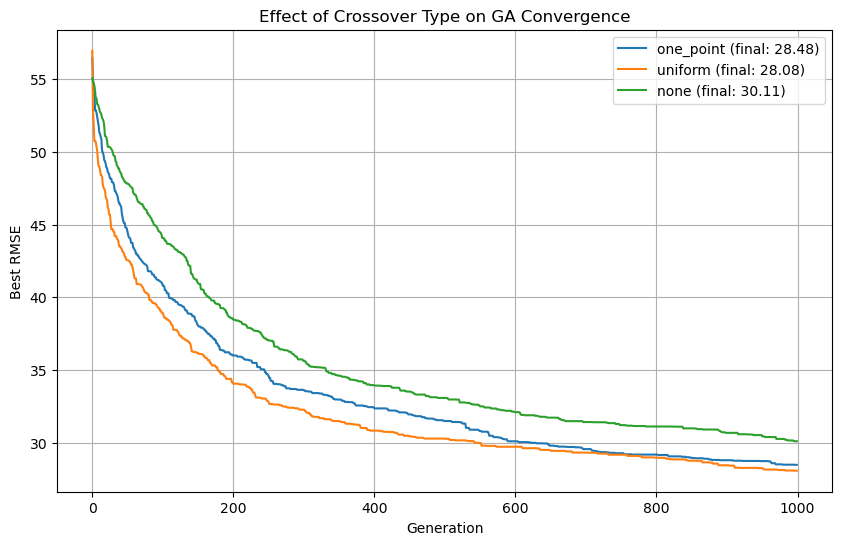

In [7]:
plt.figure(figsize=(10, 6))

for crossover_type, result in crossover_results.items():
    plt.plot(
        result["history"],
        label=f"{crossover_type} (final: {result['final_rmse']:.2f})"
    )

plt.title("Effect of Crossover Type on GA Convergence")
plt.xlabel("Generation")
plt.ylabel("Best RMSE")
plt.legend()
plt.grid(True)
plt.show()

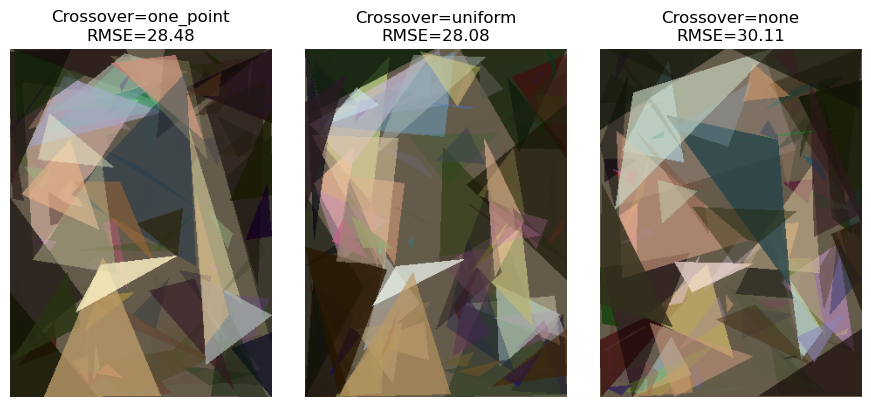

In [8]:
num_results = len(crossover_results)

fig, axes = plt.subplots(1, num_results, figsize=(3 * num_results, 4))

if num_results == 1:
    axes = [axes]

for ax, (crossover_type, result) in zip(axes, crossover_results.items()):
    ax.imshow(result["final_image"])
    ax.set_title(
        f"Crossover={crossover_type}\nRMSE={result['final_rmse']:.2f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
summary = []

for crossover_type, result in crossover_results.items():
    summary.append({
        "Crossover Type": crossover_type,
        "Final RMSE": result["final_rmse"],
        "Initial RMSE": result["history"][0],
        "Improvement": result["history"][0] - result["final_rmse"]
    })

summary_df = pd.DataFrame(summary)
summary_df

,Crossover Type,Final RMSE,Initial RMSE,Improvement
0,one_point,28.482712,56.460011,27.977299
1,uniform,28.077557,56.952950,28.875393
2,none,30.106272,55.059570,24.953299


# Results and Discussion

## Key Findings

Uniform crossover achieved the best final RMSE, suggesting that triangle-by-triangle recombination generates more useful genetic diversity than a single split point.

One-point crossover also improved over the no-crossover baseline, confirming that any form of recombination is beneficial for this problem.

The no-crossover configuration produced the worst results, demonstrating that mutation alone is insufficient to efficiently explore the solution space.

## Convergence

Uniform crossover converged faster and stabilized at a lower RMSE. One-point crossover followed a similar but slightly worse trajectory. Without crossover, convergence was noticeably slower throughout all generations.

## Conclusion

Crossover is a meaningful component of the GA for this problem. Uniform crossover was selected as the default strategy for subsequent experiments given its superior convergence behavior.